11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training with Batch GD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Stochastic GD...
Training with Mini-batch GD...
Training with Momentum GD...
Training with Nesterov GD...
Training with Adagrad...
Training with RMSprop...
Training with Adam...


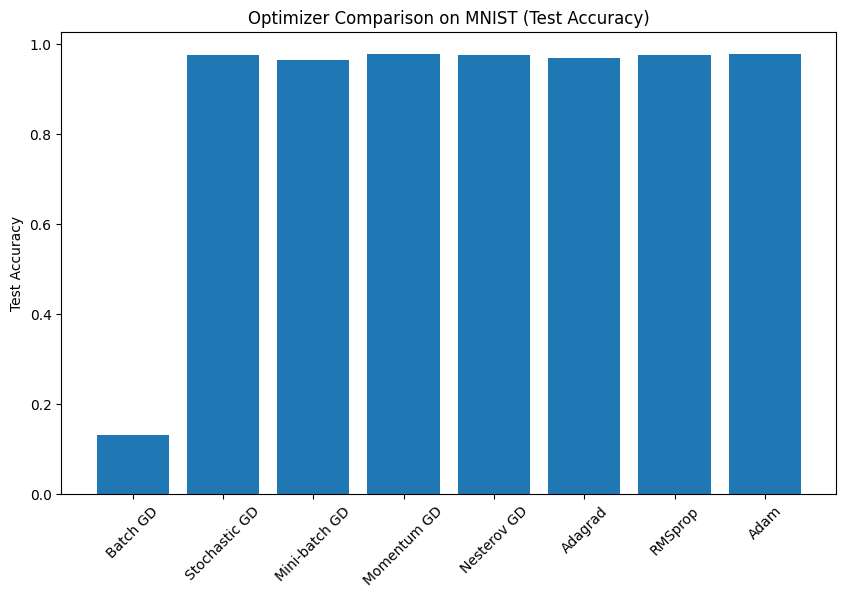

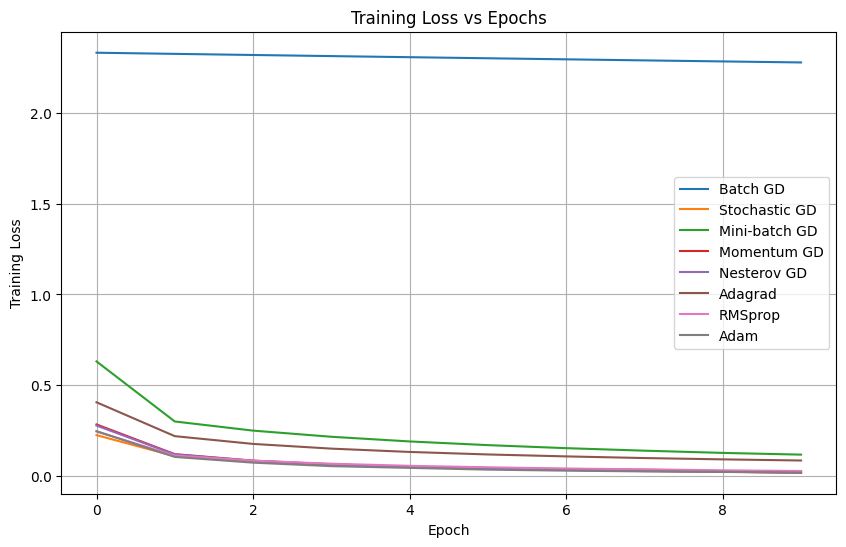

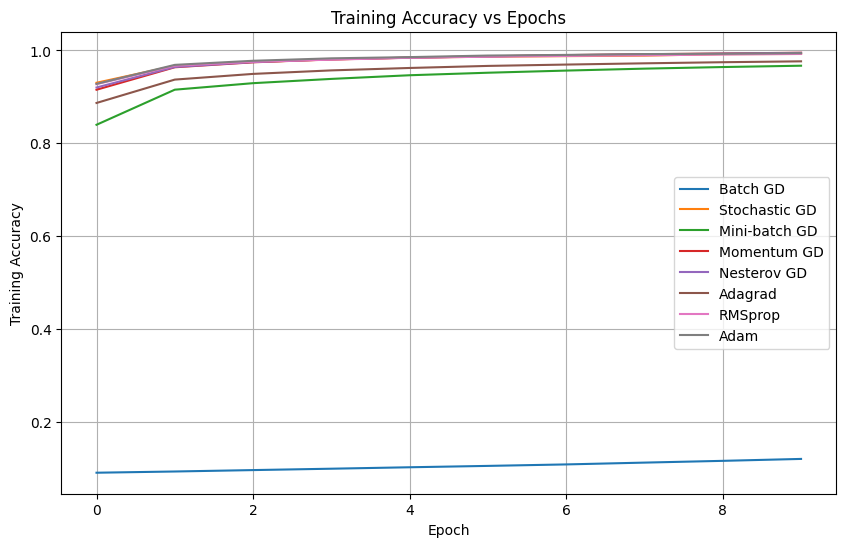


Final Test Accuracy Comparison:
Batch GD            : 0.1310
Stochastic GD       : 0.9755
Mini-batch GD       : 0.9650
Momentum GD         : 0.9779
Nesterov GD         : 0.9772
Adagrad             : 0.9705
RMSprop             : 0.9768
Adam                : 0.9783


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
from tensorflow.keras.utils import to_categorical

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocessing
X_train = X_train.reshape(60000, 784) / 255.0
X_test = X_test.reshape(10000, 784) / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Model builder
def build_mlp(optimizer):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


optimizers = {
    "Batch GD": SGD(learning_rate=0.01),
    "Stochastic GD": SGD(learning_rate=0.01),
    "Mini-batch GD": SGD(learning_rate=0.01),
    "Momentum GD": SGD(learning_rate=0.01, momentum=0.9),
    "Nesterov GD": SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "Adagrad": Adagrad(learning_rate=0.01),
    "RMSprop": RMSprop(learning_rate=0.001),
    "Adam": Adam(learning_rate=0.001)
}

results = {}
histories = {}

for name, optimizer in optimizers.items():

    print(f"Training with {name}...")

    model = build_mlp(optimizer)

    if name == "Batch GD":
        batch = 60000
    elif name == "Stochastic GD":
        batch = 1
    else:
        batch = 32

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=batch,
        verbose=0
    )

    test_acc = model.evaluate(X_test, y_test, verbose=0)[1]

    results[name] = test_acc
    histories[name] = history.history


# -----------------------
# 1️⃣ Accuracy Bar Graph
# -----------------------

plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.ylabel("Test Accuracy")
plt.title("Optimizer Comparison on MNIST (Test Accuracy)")
plt.show()


# -----------------------
# 2️⃣ Loss vs Epoch Graph
# -----------------------

plt.figure(figsize=(10,6))
for name in histories:
    plt.plot(histories[name]['loss'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------
# 3️⃣ Accuracy vs Epoch Graph
# -----------------------

plt.figure(figsize=(10,6))
for name in histories:
    plt.plot(histories[name]['accuracy'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()


# Print final comparison
print("\nFinal Test Accuracy Comparison:")
for optimizer, acc in results.items():
    print(f"{optimizer:20s}: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


BGD (SGD)                 | Final Loss: 0.0944 | Predictions: [0. 1. 1. 0.]
SGD with Momentum         | Final Loss: 0.0047 | Predictions: [0. 1. 1. 0.]
SGD with Nesterov         | Final Loss: 0.4778 | Predictions: [1. 1. 1. 0.]
Adagrad                   | Final Loss: 0.3559 | Predictions: [0. 1. 0. 0.]


RMSProp                   | Final Loss: 0.3466 | Predictions: [1. 1. 1. 0.]


Adadelta                  | Final Loss: 0.3096 | Predictions: [0. 1. 1. 0.]
Adam                      | Final Loss: 0.0206 | Predictions: [0. 1. 1. 0.]


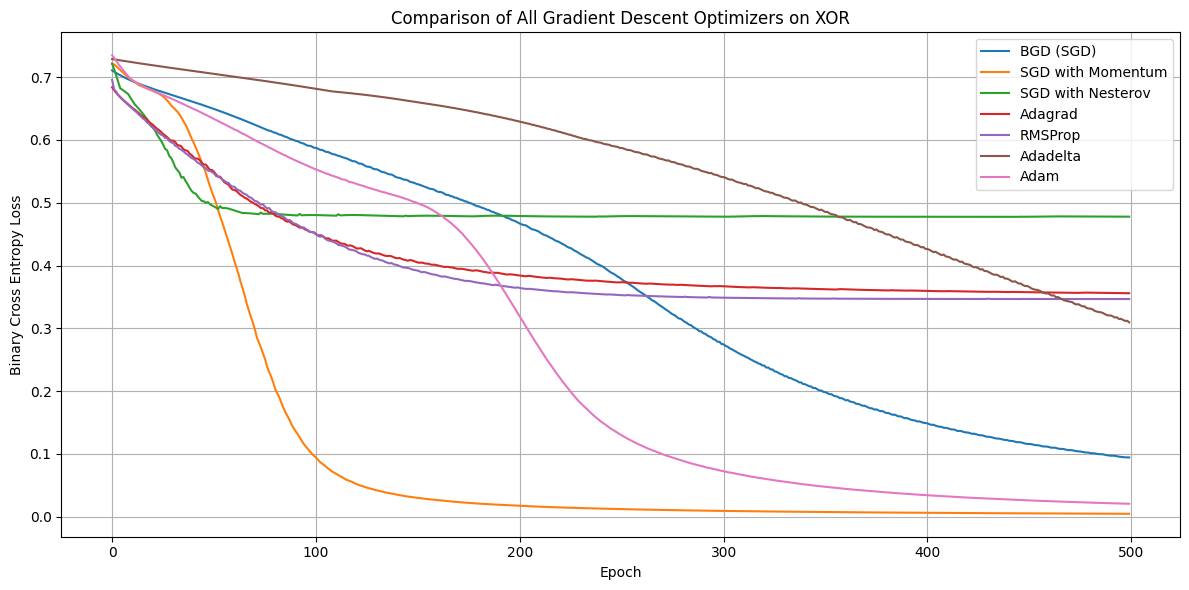

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ── Dataset: XOR ──────────────────────────────────────────
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]],         dtype=np.float32)

# ── Function to build a fresh model every time ────────────
# We build a new model for each optimizer so that
# weights are reset and each optimizer starts from scratch
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# ── All 7 Optimizers ──────────────────────────────────────
optimizers = {
    'BGD (SGD)'       : tf.keras.optimizers.SGD(learning_rate=0.1),
    'SGD with Momentum' : tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
    'SGD with Nesterov' : tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    'Adagrad'           : tf.keras.optimizers.Adagrad(learning_rate=0.1),
    'RMSProp'           : tf.keras.optimizers.RMSprop(learning_rate=0.01),
    'Adadelta'          : tf.keras.optimizers.Adadelta(learning_rate=1.0),
    'Adam'              : tf.keras.optimizers.Adam(learning_rate=0.01),
}

# ── Train each model and store loss history ────────────────
all_histories = {}

for optimizer_name, optimizer in optimizers.items():
    model = build_model()
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy'
    )
    history = model.fit(
        X, y,
        epochs=500,
        verbose=0           # Suppress per-epoch output to keep console clean
    )
    all_histories[optimizer_name] = history.history['loss']
    final_loss = history.history['loss'][-1]
    final_pred = np.round(model.predict(X, verbose=0).flatten())
    print(f"{optimizer_name:25s} | Final Loss: {final_loss:.4f} | Predictions: {final_pred}")

# ── Plot all loss curves together ─────────────────────────
plt.figure(figsize=(12, 6))
for optimizer_name, loss_values in all_histories.items():
    plt.plot(loss_values, label=optimizer_name)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Comparison of All Gradient Descent Optimizers on XOR")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


WEEK-4

In [ ]:
#XOR with All Optimizers
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# XOR data
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([[0],[1],[1],[0]])

In [ ]:
def build_xor_model():
    model = models.Sequential([
        layers.Dense(8, activation='relu', input_shape=(2,)),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
def build_xor_model():
    model = models.Sequential([
        layers.Dense(8, activation='relu', input_shape=(2,)),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
optimizers = {
    "BGD": tf.keras.optimizers.SGD(learning_rate=0.1),
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.1),
    "MiniBatch": tf.keras.optimizers.SGD(learning_rate=0.1),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
    "Nesterov": tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.1),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.01),
    "Adadelta": tf.keras.optimizers.Adadelta(),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.01)
}

In [ ]:
results_xor = {}

for name, optimizer in optimizers.items():
    model = build_xor_model()
    model.compile(loss='binary_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])

    if name == "BGD":
        batch_size = 4
    elif name == "SGD":
        batch_size = 1
    else:
        batch_size = 2

    history = model.fit(X_xor, y_xor,
                        epochs=500,
                        batch_size=batch_size,
                        verbose=0)

    loss, acc = model.evaluate(X_xor, y_xor, verbose=0)
    results_xor[name] = acc

print("XOR Results:")
for k,v in results_xor.items():
    print(k, ":", v)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


XOR Results:
BGD : 1.0
SGD : 1.0
MiniBatch : 1.0
Momentum : 1.0
Nesterov : 1.0
Adagrad : 1.0
RMSProp : 1.0
Adadelta : 0.75
Adam : 1.0


CUSTOM DATASET

MNIST

In [ ]:
import struct

def load_images(filename):
    base_path = "/content/drive/MyDrive/DL DATASETS/archive (1)"
    full_path = os.path.join(base_path, filename)
    with open(full_path,'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8)
        images = images.reshape(num, rows*cols)
        return images / 255.0

def load_labels(filename):
    base_path = "/content/drive/MyDrive/DL DATASETS/archive (1)"
    full_path = os.path.join(base_path, filename)
    with open(full_path,'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
        return labels

X_train = load_images("train-images.idx3-ubyte")
y_train = load_labels("train-labels.idx1-ubyte")
X_test = load_images("t10k-images.idx3-ubyte")
y_test = load_labels("t10k-labels.idx1-ubyte")

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
def build_mnist_model(input_dim=784):
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
tf.config.run_functions_eagerly(True)

results_mnist = {}

for name, optimizer_config in optimizers.items(): # Renamed 'optimizer' to 'optimizer_config'
    model = build_mnist_model()

    # Create a new optimizer instance for each model
    if name == "BGD" or name == "SGD" or name == "MiniBatch":
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)
    elif name == "Momentum":
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
    elif name == "Nesterov":
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True)
    elif name == "Adagrad":
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.1)
    elif name == "RMSProp":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.01)
    elif name == "Adadelta":
        optimizer = tf.keras.optimizers.Adadelta()
    elif name == "Adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    else:
        optimizer = optimizer_config # Fallback, though all are covered

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        epochs=10,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results_mnist[name] = acc

print("MNIST Results:")
for k,v in results_mnist.items():
    print(k, ":", v)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


CIFAR-10 (TAR FILE)

In [ ]:
import tarfile
import pickle
import numpy as np
import tensorflow as tf

tar = tarfile.open("/content/drive/MyDrive/DL DATASETS/cifar-10-python.tar.gz")
tar.extractall(filter='data') # Added filter='data' to address DeprecationWarning
tar.close()

def load_batch(file):
    with open(file,'rb') as f:
        dict = pickle.load(f, encoding='bytes')
        return dict[b'data'], dict[b'labels']

X_train = []
y_train = []

for i in range(1,6):
    data, labels = load_batch(f'cifar-10-batches-py/data_batch_{i}')
    X_train.append(data)
    y_train += labels

X_train = np.concatenate(X_train)/255.0
y_train = tf.keras.utils.to_categorical(y_train,10)

X_test, y_test = load_batch('cifar-10-batches-py/test_batch')
X_test = X_test/255.0
y_test = tf.keras.utils.to_categorical(y_test,10)

In [ ]:
from tensorflow.keras import layers, models # Added import for layers and models

def build_cifar_model():
    model = models.Sequential([
        layers.Dense(1024, activation='relu', input_shape=(3072,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
import tensorflow as tf # Ensure tf is imported for optimizers

optimizers = {
    "BGD": tf.keras.optimizers.SGD(learning_rate=0.1),
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.1),
    "MiniBatch": tf.keras.optimizers.SGD(learning_rate=0.1),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
    "Nesterov": tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.1),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.01),
    "Adadelta": tf.keras.optimizers.Adadelta(),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.01)
}

results_cifar = {}

for name, optimizer in optimizers.items():
    model = build_cifar_model()
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        epochs=10,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results_cifar[name] = acc

print("CIFAR Results:")
for k,v in results_cifar.items():
    print(k, ":", v)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CIFAR Results:
BGD : 0.4837999939918518
SGD : 0.4742000102996826
MiniBatch : 0.478300005197525
Momentum : 0.10000000149011612
Nesterov : 0.10000000149011612
Adagrad : 0.4603999853134155
RMSProp : 0.10010000318288803
Adadelta : 0.3643999993801117
Adam : 0.29660001397132874


WEEK-5

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tarfile
import pickle
import os

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Extract CIFAR-10
tar = tarfile.open("/content/drive/MyDrive/DL DATASETS/cifar-10-python.tar.gz")
tar.extractall()
tar.close()

/tmp/ipython-input-1486/759355522.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [ ]:
def load_cifar_batch(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
        X = dict[b'data']
        y = dict[b'labels']
        return X, y

X_train = []
y_train = []

for i in range(1, 6):
    data, labels = load_cifar_batch(f'cifar-10-batches-py/data_batch_{i}')
    X_train.append(data)
    y_train += labels

X_train = np.concatenate(X_train)
y_train = np.array(y_train)

X_test, y_test = load_cifar_batch('cifar-10-batches-py/test_batch')
y_test = np.array(y_test)

In [ ]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for MLP (flatten images)
X_train = X_train.reshape(-1, 3072)
X_test = X_test.reshape(-1, 3072)

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

input_dim = 3072
num_classes = 10

In [ ]:
def build_base_model():
    model = models.Sequential([
        layers.Dense(1024, activation='relu', input_shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
def build_dropout_model():
    model = models.Sequential([
        layers.Dense(1024, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
def add_noise(X, noise_factor=0.1):
    noise = noise_factor * np.random.randn(*X.shape)
    X_noisy = X + noise
    return np.clip(X_noisy, 0., 1.)

In [ ]:
def build_shared_model():
    shared_layer = layers.Dense(512, activation='relu')
    model = models.Sequential([
        layers.Dense(1024, activation='relu', input_shape=(input_dim,)),
        shared_layer,
        shared_layer,
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
def train_ensemble(n_models=3):
    models_list = []
    for _ in range(n_models):
        model = build_base_model()
        model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
        model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)
        models_list.append(model)
    return models_list

def ensemble_predict(models_list, X):
    preds = [model.predict(X) for model in models_list]
    return np.mean(preds, axis=0)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
model = build_dropout_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1739 - loss: 2.3633 - val_accuracy: 0.2644 - val_loss: 1.9901
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2249 - loss: 2.0403 - val_accuracy: 0.2923 - val_loss: 1.9459
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2449 - loss: 1.9982 - val_accuracy: 0.3251 - val_loss: 1.9367
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2597 - loss: 1.9727 - val_accuracy: 0.3093 - val_loss: 1.9408
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2681 - loss: 1.9654 - val_accuracy: 0.3318 - val_loss: 1.9404
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2667 - loss: 1.9542 - val_accuracy: 0.3137 - val_loss: 1.9377
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2728 - loss: 1.9474 - val_accuracy: 0.3346 - val_loss: 1.9225
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2746 - loss: 1.9328 - val_accuracy: 0.

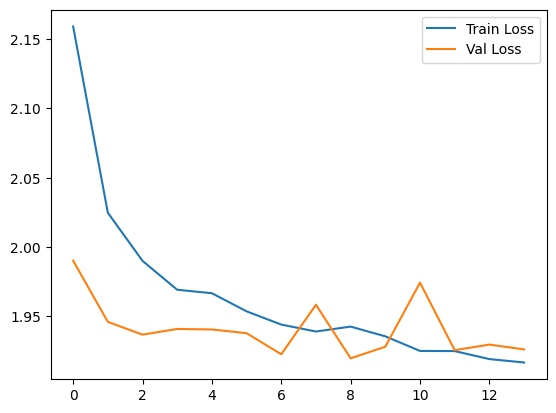

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

MNIST

In [ ]:
import numpy as np
import struct
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ============================
# 1️⃣ Function to read IDX files
# ============================

def load_mnist_images(filename):
    base_path = "/content/drive/MyDrive/DL DATASETS/archive (1)"
    full_path = os.path.join(base_path, filename)
    with open(full_path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8)
        images = images.reshape(num, rows, cols)
        return images

def load_mnist_labels(filename):
    base_path = "/content/drive/MyDrive/DL DATASETS/archive (1)"
    full_path = os.path.join(base_path, filename)
    with open(full_path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
        return labels


# ============================
# 2️⃣ Load Data
# ============================

X_train = load_mnist_images("train-images.idx3-ubyte")
y_train = load_mnist_labels("train-labels.idx1-ubyte")

X_test = load_mnist_images("t10k-images.idx3-ubyte")
y_test = load_mnist_labels("t10k-labels.idx1-ubyte")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [ ]:
# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Flatten images for MLP
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

input_dim = 784
num_classes = 10

In [ ]:
def build_base_model():
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
def build_l2_model():
    model = models.Sequential([
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=(input_dim,)),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
def build_dropout_model():
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
def add_noise(X, noise_factor=0.2):
    noise = noise_factor * np.random.randn(*X.shape)
    X_noisy = X + noise
    return np.clip(X_noisy, 0., 1.)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
def build_shared_model():
    shared_layer = layers.Dense(256, activation='relu')

    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(input_dim,)),
        shared_layer,
        shared_layer,
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
def train_ensemble(n_models=3):
    models_list = []
    for _ in range(n_models):
        model = build_base_model()
        model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
        model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)
        models_list.append(model)
    return models_list

def ensemble_predict(models_list, X):
    preds = [model.predict(X) for model in models_list]
    return np.mean(preds, axis=0)

In [ ]:
model = build_dropout_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7966 - loss: 0.6457 - val_accuracy: 0.9579 - val_loss: 0.1364
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9399 - loss: 0.1986 - val_accuracy: 0.9656 - val_loss: 0.1141
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9553 - loss: 0.1493 - val_accuracy: 0.9699 - val_loss: 0.0976
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9615 - loss: 0.1265 - val_accuracy: 0.9734 - val_loss: 0.0922
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9654 - loss: 0.1115 - val_accuracy: 0.9754 - val_loss: 0.0824
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9702 - loss: 0.0967 - val_accuracy: 0.9769 - val_loss: 0.0817
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9721 - loss: 0.0922 - val_accuracy: 0.9766 - val_loss: 0.0755
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9741 - loss: 0.0841 - val_accuracy: 0.

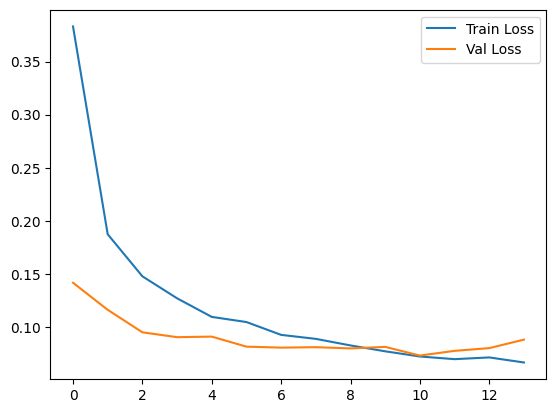

In [ ]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.show()

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, regularizers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Load Dataset ───────────────────────────────────────────
data = load_breast_cancer()
X = data.data
y = data.target

# ── Normalize the data ─────────────────────────────────────
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ── Split into train and test ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Helper function to compile and train any model ─────────
def train_and_evaluate(model, X_tr, y_tr, X_te, y_te,
                        epochs=200, callbacks=None, name=""):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_tr, y_tr,
        epochs=epochs,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=0
    )
    accuracy = model.evaluate(X_te, y_te, verbose=0)
    print(f"{name:40s} | Test Accuracy: {accuracy * 100:.2f}%")
    return history



# ══════════════════════════════════════════════════════════
# 2. L2 REGULARIZATION
# ══════════════════════════════════════════════════════════
l2_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.01),
                 input_shape=(30,)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(1,  activation='sigmoid')
])
h2 = train_and_evaluate(l2_model,
                         X_train, y_train, X_test, y_test,
                         name="2. L2 Regularization")


# ══════════════════════════════════════════════════════════
# 3. DATASET AUGMENTATION  (adding noise to inputs)
# ══════════════════════════════════════════════════════════
noise = np.random.normal(loc=0.0, scale=0.1, size=X_train.shape)
X_train_augmented = np.vstack([X_train, X_train + noise])
y_train_augmented = np.hstack([y_train, y_train])

augmentation_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(30,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])
h3 = train_and_evaluate(augmentation_model,
                         X_train_augmented, y_train_augmented,
                         X_test, y_test,
                         name="3. Dataset Augmentation")


# ══════════════════════════════════════════════════════════
# 4. PARAMETER SHARING / TYING  (L1 regularization)
# ══════════════════════════════════════════════════════════
# True parameter tying requires custom layers.
# L1 regularization is the standard way to demonstrate
# the same idea: it forces many weights to become exactly
# zero, making neurons share the burden of learning.
l1_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l1(0.01),
                 input_shape=(30,)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l1(0.01)),
    layers.Dense(1,  activation='sigmoid')
])
h4 = train_and_evaluate(l1_model,
                         X_train, y_train, X_test, y_test,
                         name="4. Parameter Sharing (L1)")


# ══════════════════════════════════════════════════════════
# 5. ADDING NOISE TO INPUTS AND OUTPUTS
# ══════════════════════════════════════════════════════════
# Keras GaussianNoise layer automatically adds random noise
# to inputs during training and turns it off during testing
noise_model = tf.keras.Sequential([
    layers.GaussianNoise(stddev=0.2, input_shape=(30,)),   # Noise on inputs
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.GaussianNoise(stddev=0.1),                      # Noise on outputs
    layers.Dense(1,  activation='sigmoid')
])
h5 = train_and_evaluate(noise_model,
                         X_train, y_train, X_test, y_test,
                         name="5. Adding Noise to Inputs/Outputs")


# ══════════════════════════════════════════════════════════
# 6. EARLY STOPPING
# ══════════════════════════════════════════════════════════
early_stop_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # Watch the validation loss
    patience=15,              # Stop if no improvement for 15 consecutive epochs
    restore_best_weights=True # After stopping, go back to the best weights seen
)

early_stop_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(30,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])
h6 = train_and_evaluate(early_stop_model,
                         X_train, y_train, X_test, y_test,
                         epochs=500,
                         callbacks=[early_stop_callback],
                         name="6. Early Stopping")


# ══════════════════════════════════════════════════════════
# 7. ENSEMBLE METHODS
# ══════════════════════════════════════════════════════════
# Train 5 separate models and average their predictions.
# Each model will learn slightly different patterns because
# of different random weight initializations.
ensemble_predictions = []

for i in range(5):
    member = tf.keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(30,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ])
    member.compile(optimizer='adam', loss='binary_crossentropy')
    member.fit(X_train, y_train, epochs=200,
               validation_split=0.1, verbose=0)
    pred = member.predict(X_test, verbose=0)
    ensemble_predictions.append(pred)

# Average all 5 model predictions
ensemble_avg  = np.mean(ensemble_predictions, axis=0)
ensemble_final = (ensemble_avg >= 0.5).astype(int).flatten()
ensemble_acc  = np.mean(ensemble_final == y_test) * 100
print(f"{'7. Ensemble (5 Models Averaged)':40s} | Test Accuracy: {ensemble_acc:.2f}%")


# ══════════════════════════════════════════════════════════
# 8. DROPOUT
# ══════════════════════════════════════════════════════════
dropout_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(30,)),
    layers.Dropout(0.4),           # Randomly turn off 40% of neurons each step
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1,  activation='sigmoid')
])
h8 = train_and_evaluate(dropout_model,
                         X_train, y_train, X_test, y_test,
                         name="8. Dropout (rate=0.4)")


# ══════════════════════════════════════════════════════════
# PLOT: Validation Loss Comparison
# ══════════════════════════════════════════════════════════
histories = {
    '1. Baseline'         : h1,
    '2. L2'               : h2,
    '3. Augmentation'     : h3,
    '4. L1 (Param Share)' : h4,
    '5. Gaussian Noise'   : h5,
    '6. Early Stopping'   : h6,
    '8. Dropout'          : h8,
}

plt.figure(figsize=(14, 6))
for label, h in histories.items():
    plt.plot(h.history['val_loss'], label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Regularization Techniques - Validation Loss Comparison")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TypeError: unsupported format string passed to list.__format__

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. Load & Prepare Data
# -------------------------------

data = load_breast_cancer()
X, y = data.data, data.target

X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 2. Helper Function
# -------------------------------

def run_model(model, name):
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=100, verbose=0)

    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print(f"{name:30s}: {acc*100:.2f}%")

# -------------------------------
# 3. BASE MODEL
# -------------------------------

base_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(30,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

run_model(base_model, "Base Model")

# -------------------------------
# 4. L2 REGULARIZATION
# -------------------------------

l2_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.01),
                 input_shape=(30,)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(1, activation='sigmoid')
])

run_model(l2_model, "L2 Regularization")

# -------------------------------
# 5. DATA AUGMENTATION (Noise)
# -------------------------------

noise = np.random.normal(0, 0.1, X_train.shape)
X_aug = np.vstack([X_train, X_train + noise])
y_aug = np.hstack([y_train, y_train])

aug_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(30,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

aug_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
aug_model.fit(X_aug, y_aug, epochs=100, verbose=0)

acc = aug_model.evaluate(X_test, y_test, verbose=0)[1]
print(f"{'Data Augmentation':30s}: {acc*100:.2f}%")

# -------------------------------
# 6. L1 (Parameter Sharing idea)
# -------------------------------

l1_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l1(0.01),
                 input_shape=(30,)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l1(0.01)),
    layers.Dense(1, activation='sigmoid')
])

run_model(l1_model, "L1 Regularization")

# -------------------------------
# 7. ADDING NOISE (Layer)
# -------------------------------

noise_model = tf.keras.Sequential([
    layers.GaussianNoise(0.1, input_shape=(30,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

run_model(noise_model, "Noise Injection")

# -------------------------------
# 8. EARLY STOPPING
# -------------------------------

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss', patience=10
)

early_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(30,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

early_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_model.fit(X_train, y_train, epochs=200,
                callbacks=[early_stop], verbose=0)

acc = early_model.evaluate(X_test, y_test)[1]
print(f"{'Early Stopping':30s}: {acc*100:.2f}%")

# -------------------------------
# 9. DROPOUT
# -------------------------------

drop_model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(30,)),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

run_model(drop_model, "Dropout")

# -------------------------------
# 10. ENSEMBLE (Simple)
# -------------------------------

preds = []

for i in range(3):
    model = tf.keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(30,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.fit(X_train, y_train, epochs=100, verbose=0)
    preds.append(model.predict(X_test))

final_pred = np.mean(preds, axis=0)
final_pred = (final_pred > 0.5).astype(int)

ensemble_acc = np.mean(final_pred.flatten() == y_test) * 100
print(f"{'Ensemble':30s}: {ensemble_acc:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Base Model                    : 97.37%
L2 Regularization             : 97.37%
Data Augmentation             : 97.37%
L1 Regularization             : 98.25%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Noise Injection               : 95.61%
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9737 - loss: 0.1869
Early Stopping                : 97.37%
Dropout                       : 98.25%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Ensemble                      : 97.37%
